In [1]:
!pip -q install "transformers>=4.51,<4.58" "accelerate>=0.30,<1.0" "pillow>=10,<12"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.6 MB/s eta 0:00:00


In [3]:
import json
import math
import os
from pathlib import Path

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

In [4]:
import torch
import PIL

print("Torch version:", torch.__version__)
print("Pillow version:", PIL.__version__)
print("CUDA available:", torch.cuda.is_available())

from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

print("Imports successful")

Torch version: 2.10.0+cpu
Pillow version: 11.3.0
CUDA available: False
Imports successful


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: False
Device: cpu


In [10]:
import json
import os

# Change this path if your file is elsewhere
TRAIN_JSON = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v2/splits/train.json"

# Load dataset
with open(TRAIN_JSON, "r") as f:
    data = json.load(f)

print("Total rows in train.json:", len(data))

# Keep only pointing samples
pointing_samples = [
    sample for sample in data
    if sample.get("collection_method") == "pointing"
]

print("Total pointing samples:", len(pointing_samples))

# Show one sample
print("\nExample sample:")
print(pointing_samples[0])

Total rows in train.json: 579
Total pointing samples: 253

Example sample:
{'id': 347231, 'label': 'watch', 'collection_method': 'pointing', 'count': None, 'points': [{'x': 92.39222995228073, 'y': 62.40673709093595}], 'image_path': '/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v2/images/watch_10.jpg', 'image_url': 'https://www.masslive.com/resizer/v2/OUFOROCHOBFM7LT7J35LKWYJQE.jpg?auth=a99fc90b0cc759e9e567d67d3a04f5e3b0a7a518b053441fe57facf4fa78bf05&width=1280&quality=90'}


In [11]:
import os

IMAGES_DIR = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v2/images"

print("Exists:", os.path.exists(IMAGES_DIR))
print("Some files:", os.listdir(IMAGES_DIR)[:10])

Exists: True
Some files: ['book_0.jpg', 'fork_0.jpg', 'shoe_1.jpg', 'shoe_3.jpg', 'spoon_0.jpg', 'shoe_2.jpg', 'shoe_0.jpg', 'shoe_4.jpg', 'cup_0.jpg', 'bowl_0.jpg']


Label: watch
JSON image path: /content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v2/images/watch_10.jpg
Filename: watch_10.jpg
Real image path: /content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v2/images/watch_10.jpg
Ground truth points: [{'x': 92.39222995228073, 'y': 62.40673709093595}]
Exists: True
Image size: (1280, 1113)


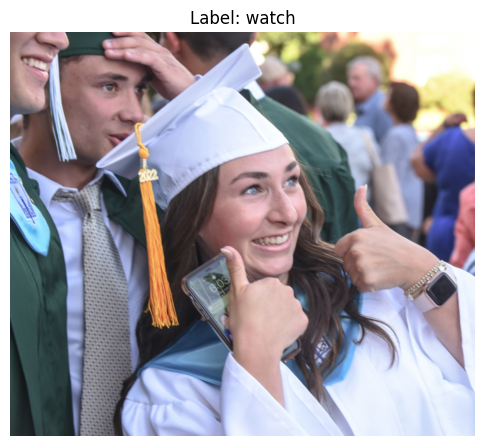

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample = pointing_samples[0]

label = sample["label"]
gt_points = sample["points"]

# OLD path from JSON
json_image_path = sample["image_path"]

# Take only filename, like watch_10.jpg
filename = os.path.basename(json_image_path)

# Build correct path using your real images folder
real_image_path = os.path.join(IMAGES_DIR, filename)

print("Label:", label)
print("JSON image path:", json_image_path)
print("Filename:", filename)
print("Real image path:", real_image_path)
print("Ground truth points:", gt_points)
print("Exists:", os.path.exists(real_image_path))

# Load image using REAL path, not old JSON path
image = Image.open(real_image_path).convert("RGB")
print("Image size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [14]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

print("Using device:", DEVICE)
print("GroundingDINO loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Using device: cpu
GroundingDINO loaded successfully


Prompt: point to the watch.
Ground truth point (0-100): (92.39222995228073, 62.40673709093595)
Ground truth point (pixels): (1182.6205433891932, 694.5869838221171)
Number of detections: 2
Best box: [1080.8774  623.8    1235.7708  777.7777]
Best score: 0.5249322652816772
Best matched text: watch
Predicted point (pixels): (np.float32(1158.3241), np.float32(700.7888))
Predicted point (0-100): (np.float32(90.49407), np.float32(62.963955))
Error: 1.9782526


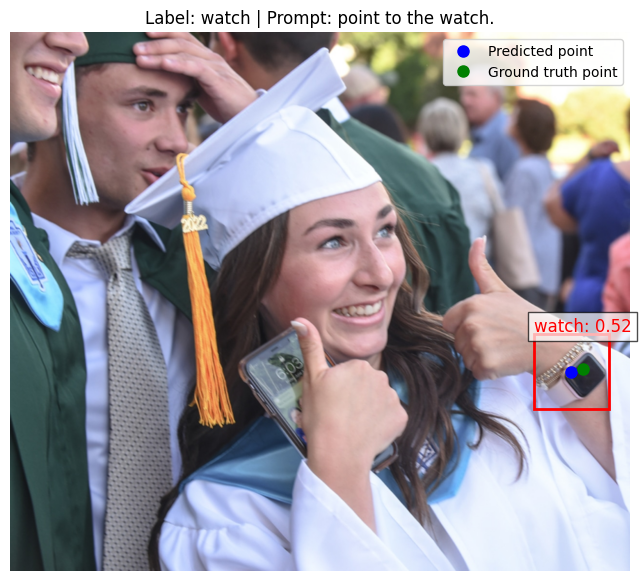

In [19]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

prompt = f"point to the {label}."
print("Prompt:", prompt)

gt_x, gt_y = gt_points[0]["x"], gt_points[0]["y"]

img_w, img_h = image.size
gt_x_px = (gt_x / 100.0) * img_w
gt_y_px = (gt_y / 100.0) * img_h

print("Ground truth point (0-100):", (gt_x, gt_y))
print("Ground truth point (pixels):", (gt_x_px, gt_y_px))

inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)  # (height, width)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=target_sizes,
    threshold=0.3,
    text_threshold=0.25
)

result = results[0]
boxes = result["boxes"]
scores = result["scores"]
labels_out = result["labels"]

print("Number of detections:", len(boxes))

if len(boxes) == 0:
    print("No detections found.")
else:
    best_idx = scores.argmax().item()
    best_box = boxes[best_idx].detach().cpu().numpy()
    best_score = scores[best_idx].item()
    best_label = labels_out[best_idx]

    x1, y1, x2, y2 = best_box
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    pred_x_norm = (center_x / img_w) * 100.0
    pred_y_norm = (center_y / img_h) * 100.0

    error = ((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2) ** 0.5

    print("Best box:", best_box)
    print("Best score:", best_score)
    print("Best matched text:", best_label)
    print("Predicted point (pixels):", (center_x, center_y))
    print("Predicted point (0-100):", (pred_x_norm, pred_y_norm))
    print("Error:", error)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.plot(center_x, center_y, "bo", markersize=8, label="Predicted point")
    ax.plot(gt_x_px, gt_y_px, "go", markersize=8, label="Ground truth point")

    ax.text(
        x1,
        max(0, y1 - 5),
        f"{best_label}: {best_score:.2f}",
        color="red",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.7)
    )

    ax.legend()
    plt.title(f"Label: {label} | Prompt: {prompt}")
    plt.axis("off")
    plt.show()

In [21]:
import os
import math
import torch

def get_first_gt_point(sample):
    points = sample.get("points", [])
    if not points:
        return None
    return float(points[0]["x"]), float(points[0]["y"])

def build_prompt(label):
    return f"point to the {label}."

def compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y):
    return math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

results_log = []

for sample in pointing_samples[:10]:
    label = sample["label"]
    gt_point = get_first_gt_point(sample)

    if gt_point is None:
        continue

    gt_x, gt_y = gt_point

    filename = os.path.basename(sample["image_path"])
    real_image_path = os.path.join(IMAGES_DIR, filename)

    if not os.path.exists(real_image_path):
        print("Missing image:", real_image_path)
        continue

    image = Image.open(real_image_path).convert("RGB")
    img_w, img_h = image.size
    prompt = build_prompt(label)

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=0.3,
        text_threshold=0.25
    )

    result = results[0]
    boxes = result["boxes"]
    scores = result["scores"]
    labels_out = result["labels"]

    if len(boxes) == 0:
        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": None,
            "error": None,
            "status": "no_detection"
        }
    else:
        best_idx = scores.argmax().item()
        best_box = boxes[best_idx].detach().cpu().numpy()
        best_score = scores[best_idx].item()
        best_label = labels_out[best_idx]

        x1, y1, x2, y2 = best_box
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        pred_x_norm = (center_x / img_w) * 100.0
        pred_y_norm = (center_y / img_h) * 100.0

        error = compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": (pred_x_norm, pred_y_norm),
            "error": error,
            "score": best_score,
            "best_label": best_label,
            "status": "ok"
        }

    results_log.append(row)
    print(row)

valid_errors = [r["error"] for r in results_log if r["error"] is not None]
if valid_errors:
    mean_error = sum(valid_errors) / len(valid_errors)
    print("\nMean error over first 10 pointing samples:", mean_error)
else:
    print("\nNo valid detections found.")

{'id': 347231, 'label': 'watch', 'prompt': 'point to the watch.', 'filename': 'watch_10.jpg', 'gt_point': (92.39222995228073, 62.40673709093595), 'pred_point': (np.float32(90.49407), np.float32(62.963955)), 'error': 1.978252668313616, 'score': 0.5249322652816772, 'best_label': 'watch', 'status': 'ok'}
{'id': 352423, 'label': 'bag', 'prompt': 'point to the bag.', 'filename': 'bag_14.jpg', 'gt_point': (19.345238095238095, 60.79365079365079), 'pred_point': (np.float32(19.926865), np.float32(59.546696)), 'error': 1.375931987487161, 'score': 0.3063810467720032, 'best_label': 'bag', 'status': 'ok'}
{'id': 704726, 'label': 'wallet', 'prompt': 'point to the wallet.', 'filename': 'wallet_7.jpg', 'gt_point': (13.988910308065567, 18.868615593459158), 'pred_point': (np.float32(50.0521), np.float32(49.895405)), 'error': 47.57326278521634, 'score': 0.4046526551246643, 'best_label': 'the wallet', 'status': 'ok'}
{'id': 837955, 'label': 'toothbrush', 'prompt': 'point to the toothbrush.', 'filename': '

In [23]:
import os
import math
import torch

def get_first_gt_point(sample):
    points = sample.get("points", [])
    if not points:
        return None
    return float(points[0]["x"]), float(points[0]["y"])

def compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y):
    return math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

prompt_templates = [
    "{label}.",
    "point to the {label}.",
    "grasp the {label}.",
    "hold the {label}."
]

all_results = []

for template in prompt_templates:
    print("\n==============================")
    print("Testing prompt template:", template)
    print("==============================")

    results_log = []

    for sample in pointing_samples[:10]:
        label = sample["label"]
        gt_point = get_first_gt_point(sample)

        if gt_point is None:
            continue

        gt_x, gt_y = gt_point

        filename = os.path.basename(sample["image_path"])
        real_image_path = os.path.join(IMAGES_DIR, filename)

        if not os.path.exists(real_image_path):
            print("Missing image:", real_image_path)
            continue

        image = Image.open(real_image_path).convert("RGB")
        img_w, img_h = image.size

        # Build prompt here
        prompt = template.format(label=label)

        inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            target_sizes=target_sizes,
            threshold=0.3,
            text_threshold=0.25
        )

        result = results[0]
        boxes = result["boxes"]
        scores = result["scores"]
        labels_out = result["labels"]

        if len(boxes) == 0:
            row = {
                "id": sample["id"],
                "label": label,
                "prompt": prompt,
                "filename": filename,
                "gt_point": (gt_x, gt_y),
                "pred_point": None,
                "error": None,
                "status": "no_detection"
            }
        else:
            best_idx = scores.argmax().item()
            best_box = boxes[best_idx].detach().cpu().numpy()
            best_score = scores[best_idx].item()
            best_label = labels_out[best_idx]

            x1, y1, x2, y2 = best_box
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2

            pred_x_norm = (center_x / img_w) * 100.0
            pred_y_norm = (center_y / img_h) * 100.0

            error = compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

            row = {
                "id": sample["id"],
                "label": label,
                "prompt": prompt,
                "filename": filename,
                "gt_point": (gt_x, gt_y),
                "pred_point": (pred_x_norm, pred_y_norm),
                "error": error,
                "score": best_score,
                "best_label": best_label,
                "status": "ok"
            }

        results_log.append(row)
        print(row)

    valid_errors = [r["error"] for r in results_log if r["error"] is not None]
    mean_error = sum(valid_errors) / len(valid_errors) if valid_errors else None

    print("\nMean error for template:", template, "=", mean_error)

    all_results.append({
        "template": template,
        "mean_error": mean_error,
        "details": results_log
    })


Testing prompt template: {label}.
{'id': 347231, 'label': 'watch', 'prompt': 'watch.', 'filename': 'watch_10.jpg', 'gt_point': (92.39222995228073, 62.40673709093595), 'pred_point': (np.float32(90.39111), np.float32(63.061916)), 'error': 2.1056389394849586, 'score': 0.6068662405014038, 'best_label': 'watch', 'status': 'ok'}
{'id': 352423, 'label': 'bag', 'prompt': 'bag.', 'filename': 'bag_14.jpg', 'gt_point': (19.345238095238095, 60.79365079365079), 'pred_point': None, 'error': None, 'status': 'no_detection'}
{'id': 704726, 'label': 'wallet', 'prompt': 'wallet.', 'filename': 'wallet_7.jpg', 'gt_point': (13.988910308065567, 18.868615593459158), 'pred_point': (np.float32(50.069332), np.float32(49.88658)), 'error': 47.58057259714173, 'score': 0.39391443133354187, 'best_label': 'wallet', 'status': 'ok'}
{'id': 837955, 'label': 'toothbrush', 'prompt': 'toothbrush.', 'filename': 'toothbrush_12.jpg', 'gt_point': (18.81484936405412, 34.89355226492458), 'pred_point': (np.float32(16.080103), np.

In [25]:
import os
import math
import torch

def get_first_gt_point(sample):
    points = sample.get("points", [])
    if not points:
        return None
    return float(points[0]["x"]), float(points[0]["y"])

def compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y):
    return math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

results_log = []

for sample in pointing_samples[:50]: # Changed train_pointing to pointing_samples
    label = sample["label"]
    gt_point = get_first_gt_point(sample)

    if gt_point is None:
        continue

    gt_x, gt_y = gt_point

    filename = os.path.basename(sample["image_path"])
    real_image_path = os.path.join(IMAGES_DIR, filename)

    if not os.path.exists(real_image_path):
        continue

    image = Image.open(real_image_path).convert("RGB")
    img_w, img_h = image.size

    # Best prompt from your experiment
    prompt = f"{label}."

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=0.3,
        text_threshold=0.25
    )

    result = results[0]
    boxes = result["boxes"]
    scores = result["scores"]
    labels_out = result["labels"]

    if len(boxes) == 0:
        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": None,
            "error": None,
            "status": "no_detection"
        }
    else:
        best_idx = scores.argmax().item()
        best_box = boxes[best_idx].detach().cpu().numpy()
        best_score = scores[best_idx].item()
        best_label = labels_out[best_idx]

        x1, y1, x2, y2 = best_box
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        pred_x_norm = (center_x / img_w) * 100.0
        pred_y_norm = (center_y / img_h) * 100.0

        error = compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": (pred_x_norm, pred_y_norm),
            "error": error,
            "score": best_score,
            "best_label": best_label,
            "status": "ok"
        }

    results_log.append(row)

valid_errors = [r["error"] for r in results_log if r["error"] is not None]
num_ok = sum(1 for r in results_log if r["status"] == "ok")
num_fail = sum(1 for r in results_log if r["status"] == "no_detection")

print("Total tested:", len(results_log))
print("Successful detections:", num_ok)
print("No detections:", num_fail)

if valid_errors:
    print("Mean error:", sum(valid_errors) / len(valid_errors))

Total tested: 50
Successful detections: 43
No detections: 7
Mean error: 13.213297734460864


In [26]:
import pandas as pd
import numpy as np

# Convert logs to dataframe
df_results = pd.DataFrame(results_log)

# Basic metrics
total_tested = len(df_results)
num_ok = (df_results["status"] == "ok").sum()
num_fail = (df_results["status"] == "no_detection").sum()
detection_rate = num_ok / total_tested if total_tested > 0 else 0.0

valid_df = df_results[df_results["error"].notna()].copy()

print("----- Summary -----")
print("Total tested:", total_tested)
print("Successful detections:", num_ok)
print("No detections:", num_fail)
print("Detection rate:", round(detection_rate * 100, 2), "%")

if len(valid_df) > 0:
    print("Mean error:", valid_df["error"].mean())
    print("Median error:", valid_df["error"].median())
    print("Min error:", valid_df["error"].min())
    print("Max error:", valid_df["error"].max())
else:
    print("No valid detections to evaluate.")

# Best and worst samples
if len(valid_df) > 0:
    best_5 = valid_df.sort_values("error").head(5)
    worst_5 = valid_df.sort_values("error", ascending=False).head(5)

    print("\n----- Best 5 samples -----")
    display(best_5[["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]])

    print("\n----- Worst 5 samples -----")
    display(worst_5[["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]])

# Save results if you want
save_path = "/content/groundingdino_first50_results.csv"
df_results.to_csv(save_path, index=False)
print(f"\nSaved results to: {save_path}")

----- Summary -----
Total tested: 50
Successful detections: 43
No detections: 7
Detection rate: 86.0 %
Mean error: 13.213297734460866
Median error: 2.9782831620350874
Min error: 0.3387960859564937
Max error: 88.77102798861941

----- Best 5 samples -----


,id,label,filename,gt_point,pred_point,error,score,best_label
6,396104,backpack,backpack_16.jpg,"(34.345238095238095, 73.92385131835047)","(34.67919, 73.866776)",0.338796,0.459044,backpack
31,430212,mouse,mouse_16.jpg,"(61.03753923667197, 77.0781237225621)","(61.248867, 76.75351)",0.387342,0.696146,mouse
32,1304130,stapler,stapler_6.jpg,"(33.46706037950438, 50.811395729290844)","(33.399067, 50.42814)",0.389243,0.519267,stapler
29,802764,toothbrush,toothbrush_11.jpg,"(75.35714285714286, 61.904761904761905)","(75.04602, 61.45224)",0.549155,0.724807,toothbrush
24,458523,mouse,mouse_18.jpg,"(49.62629992350258, 58.96783044304923)","(50.098057, 59.408604)",0.645627,0.523096,mouse



----- Worst 5 samples -----


,id,label,filename,gt_point,pred_point,error,score,best_label
27,1116506,highlighter,highlighter_4.jpg,"(91.40897679260303, 95.27412265781273)","(24.281284, 37.186523)",88.771028,0.634908,highlighter
25,533313,notebook,notebook_10.jpg,"(80.01152177069216, 92.59418487548828)","(54.05091, 49.91201)",49.957194,0.927293,notebook
45,1978555,stapler,stapler_12.jpg,"(88.39285714285714, 77.45106769488326)","(49.920876, 47.831795)",48.553010,0.647153,stapler
2,704726,wallet,wallet_7.jpg,"(13.988910308065567, 18.868615593459158)","(50.069332, 49.88658)",47.580573,0.393914,wallet
19,955335,wallet,wallet_11.jpg,"(21.817841949047224, 85.84071225777998)","(57.018005, 57.28112)",45.328822,0.402601,wallet



Saved results to: /content/groundingdino_first50_results.csv


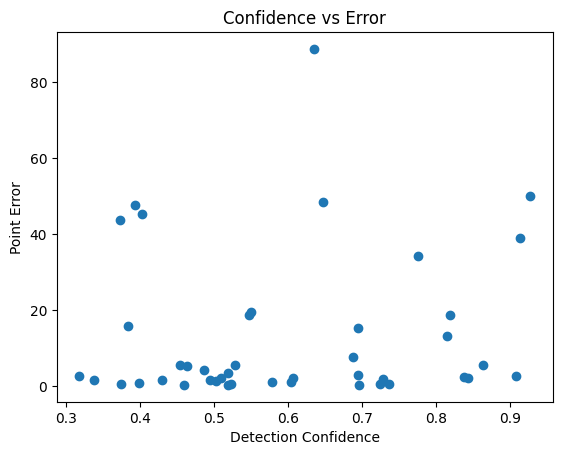

In [27]:
import matplotlib.pyplot as plt

valid_df = df_results[df_results["error"].notna()]

plt.scatter(valid_df["score"], valid_df["error"])
plt.xlabel("Detection Confidence")
plt.ylabel("Point Error")
plt.title("Confidence vs Error")
plt.show()

In [28]:
filtered_df = valid_df[valid_df["score"] > 0.5]

print("Mean error (filtered):", filtered_df["error"].mean())

Mean error (filtered): 13.487730289407622


In [29]:
failed_df = df_results[df_results["status"] == "no_detection"].copy()
print("----- No-detection samples -----")
display(failed_df[["id", "label", "filename", "gt_point", "prompt", "status"]])

----- No-detection samples -----


,id,label,filename,gt_point,prompt,status
1,352423,bag,bag_14.jpg,"(19.345238095238095, 60.79365079365079)",bag.,no_detection
18,372642,jar,jar_17.jpg,"(76.34920619782947, 88.67409299275899)",jar.,no_detection
20,354912,onion,onion_15.jpg,"(23.50649424961635, 87.12560926164899)",onion.,no_detection
21,1152736,stapler,stapler_5.jpg,"(56.78828493422685, 34.17152131672043)",stapler.,no_detection
26,581279,remote,remote_8.jpg,"(48.129687961474126, 74.06840123754934)",remote.,no_detection
38,1467387,highlighter,highlighter_6.jpg,"(83.21428571428572, 42.0341676599126)",highlighter.,no_detection
44,429532,tape,tape_16.jpg,"(25.2849672555715, 5.278698800745616)",tape.,no_detection


In [30]:
print("----- No-detection count by label -----")
print(failed_df["label"].value_counts())

----- No-detection count by label -----
label
bag            1
jar            1
onion          1
stapler        1
remote         1
highlighter    1
tape           1
Name: count, dtype: int64


In [34]:
import json
import os

BASE_DIR = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v2/splits" # Corrected path

train_json_path = os.path.join(BASE_DIR, "train.json")
val_json_path = os.path.join(BASE_DIR, "val.json")
test_json_path = os.path.join(BASE_DIR, "test.json")

with open(train_json_path, "r") as f:
    train_data = json.load(f)

with open(val_json_path, "r") as f:
    val_data = json.load(f)

with open(test_json_path, "r") as f:
    test_data = json.load(f)

print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print("Test samples:", len(test_data))

Train samples: 579
Val samples: 50
Test samples: 100


In [35]:
val_pointing = [s for s in val_data if s.get("collection_method") == "pointing"]
print("Validation pointing samples:", len(val_pointing))

Validation pointing samples: 28


In [38]:
from collections import Counter

print("Train collection_method counts:", Counter(s.get("collection_method", "missing") for s in train_data))
print("Val collection_method counts:", Counter(s.get("collection_method", "missing") for s in val_data))
print("Test collection_method counts:", Counter(s.get("collection_method", "missing") for s in test_data))

Train collection_method counts: Counter({'counting': 326, 'pointing': 253})
Val collection_method counts: Counter({'pointing': 28, 'counting': 22})
Test collection_method counts: Counter({'counting': 57, 'pointing': 43})


In [39]:
import os
import math
import torch
import pandas as pd
from PIL import Image

def get_first_gt_point(sample):
    points = sample.get("points", [])
    if not points:
        return None
    return float(points[0]["x"]), float(points[0]["y"])

def compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y):
    return math.sqrt((pred_x_norm - gt_x) ** 2 + (pred_y_norm - gt_y) ** 2)

val_results_log = []

for sample in val_pointing:
    label = sample["label"]
    gt_point = get_first_gt_point(sample)
    if gt_point is None:
        continue

    gt_x, gt_y = gt_point

    filename = os.path.basename(sample["image_path"])
    real_image_path = os.path.join(IMAGES_DIR, filename)

    if not os.path.exists(real_image_path):
        print("Missing image:", real_image_path)
        continue

    image = Image.open(real_image_path).convert("RGB")
    img_w, img_h = image.size

    prompt = f"{label}."

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

    processed = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=0.3,
        text_threshold=0.25
    )

    result = processed[0]
    boxes = result["boxes"]
    scores = result["scores"]
    labels_out = result["labels"]

    if len(boxes) == 0:
        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": None,
            "error": None,
            "score": None,
            "best_label": None,
            "status": "no_detection"
        }
    else:
        best_idx = scores.argmax().item()
        best_box = boxes[best_idx].detach().cpu().numpy()
        best_score = scores[best_idx].item()
        best_label = labels_out[best_idx]

        x1, y1, x2, y2 = best_box
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        pred_x_norm = (center_x / img_w) * 100.0
        pred_y_norm = (center_y / img_h) * 100.0

        error = compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": (pred_x_norm, pred_y_norm),
            "error": error,
            "score": best_score,
            "best_label": best_label,
            "status": "ok"
        }

    val_results_log.append(row)

print("Validation loop done. Rows:", len(val_results_log))

Validation loop done. Rows: 28


In [40]:
val_df_results = pd.DataFrame(val_results_log)
val_valid_df = val_df_results[val_df_results["error"].notna()].copy()

print("----- Validation Summary -----")
print("Total tested:", len(val_df_results))
print("Successful detections:", (val_df_results["status"] == "ok").sum())
print("No detections:", (val_df_results["status"] == "no_detection").sum())

if len(val_df_results) > 0:
    detection_rate = (val_df_results["status"] == "ok").sum() / len(val_df_results)
    print("Detection rate:", round(detection_rate * 100, 2), "%")

if len(val_valid_df) > 0:
    print("Mean error:", val_valid_df["error"].mean())
    print("Median error:", val_valid_df["error"].median())
    print("Min error:", val_valid_df["error"].min())
    print("Max error:", val_valid_df["error"].max())

    print("\n----- Validation Best 5 -----")
    display(val_valid_df.sort_values("error").head(5)[
        ["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]
    ])

    print("\n----- Validation Worst 5 -----")
    display(val_valid_df.sort_values("error", ascending=False).head(5)[
        ["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]
    ])

val_save_path = "/content/groundingdino_val_results.csv"
val_df_results.to_csv(val_save_path, index=False)
print(f"\nSaved validation results to: {val_save_path}")

----- Validation Summary -----
Total tested: 28
Successful detections: 23
No detections: 5
Detection rate: 82.14 %
Mean error: 12.487224731953834
Median error: 5.7535651391378835
Min error: 0.8213895357523809
Max error: 49.086665525597425

----- Validation Best 5 -----


,id,label,filename,gt_point,pred_point,error,score,best_label
4,663464,kettle,kettle_6.jpg,"(81.359129406157, 80.48249457196029)","(81.6999, 79.73513)",0.821390,0.351237,kettle
1,322777,watch,watch_1.jpg,"(73.96946220249032, 77.33338949548632)","(74.44737, 78.14841)",0.944804,0.611906,watch
16,327798,mouse,mouse_2.jpg,"(26.488095238095237, 34.579893152015536)","(25.434776, 35.00545)",1.136036,0.791609,mouse
20,404152,umbrella,umbrella_18.jpg,"(45.0, 27.504481073117283)","(44.586666, 28.758945)",1.320806,0.707006,umbrella
17,473405,calculator,calculator_6.jpg,"(26.25, 84.17826586642829)","(26.951471, 85.465904)",1.466311,0.631634,calculator



----- Validation Worst 5 -----


,id,label,filename,gt_point,pred_point,error,score,best_label
22,1056768,kettle,kettle_15.jpg,"(2.1026854590598703, 62.92142387536012)","(50.00692, 52.212322)",49.086666,0.501738,kettle
11,348097,scissor,scissor_0.jpg,"(46.40818050893542, 6.53708852173252)","(24.206629, 50.290913)",49.064304,0.450490,scissor
3,642624,charger,charger_4.jpg,"(43.392857142857146, 88.09523809523809)","(48.479774, 47.36564)",41.046035,0.467311,charger
9,394323,backpack,backpack_14.jpg,"(67.55555555555556, 72.58333333333333)","(37.563496, 63.97008)",31.204357,0.330732,backpack
23,353201,jar,jar_15.jpg,"(55.35714285714286, 50.95238095238095)","(66.957565, 71.041275)",23.197703,0.775593,jar



Saved validation results to: /content/groundingdino_val_results.csv


In [41]:
test_pointing = [s for s in test_data if s.get("collection_method") == "pointing"]
print("Test pointing samples:", len(test_pointing))

Test pointing samples: 43


In [42]:
test_results_log = []

for sample in test_pointing:
    label = sample["label"]
    gt_point = get_first_gt_point(sample)
    if gt_point is None:
        continue

    gt_x, gt_y = gt_point

    filename = os.path.basename(sample["image_path"])
    real_image_path = os.path.join(IMAGES_DIR, filename)

    if not os.path.exists(real_image_path):
        print("Missing image:", real_image_path)
        continue

    image = Image.open(real_image_path).convert("RGB")
    img_w, img_h = image.size

    prompt = f"{label}."

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(DEVICE)

    processed = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=target_sizes,
        threshold=0.3,
        text_threshold=0.25
    )

    result = processed[0]
    boxes = result["boxes"]
    scores = result["scores"]
    labels_out = result["labels"]

    if len(boxes) == 0:
        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": None,
            "error": None,
            "score": None,
            "best_label": None,
            "status": "no_detection"
        }
    else:
        best_idx = scores.argmax().item()
        best_box = boxes[best_idx].detach().cpu().numpy()
        best_score = scores[best_idx].item()
        best_label = labels_out[best_idx]

        x1, y1, x2, y2 = best_box
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        pred_x_norm = (center_x / img_w) * 100.0
        pred_y_norm = (center_y / img_h) * 100.0

        error = compute_error(pred_x_norm, pred_y_norm, gt_x, gt_y)

        row = {
            "id": sample["id"],
            "label": label,
            "prompt": prompt,
            "filename": filename,
            "gt_point": (gt_x, gt_y),
            "pred_point": (pred_x_norm, pred_y_norm),
            "error": error,
            "score": best_score,
            "best_label": best_label,
            "status": "ok"
        }

    test_results_log.append(row)

print("Test loop done. Rows:", len(test_results_log))

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Test loop done. Rows: 43


In [43]:
test_df_results = pd.DataFrame(test_results_log)
test_valid_df = test_df_results[test_df_results["error"].notna()].copy()

print("----- Test Summary -----")
print("Total tested:", len(test_df_results))
print("Successful detections:", (test_df_results["status"] == "ok").sum())
print("No detections:", (test_df_results["status"] == "no_detection").sum())

if len(test_df_results) > 0:
    detection_rate = (test_df_results["status"] == "ok").sum() / len(test_df_results)
    print("Detection rate:", round(detection_rate * 100, 2), "%")

if len(test_valid_df) > 0:
    print("Mean error:", test_valid_df["error"].mean())
    print("Median error:", test_valid_df["error"].median())
    print("Min error:", test_valid_df["error"].min())
    print("Max error:", test_valid_df["error"].max())

    print("\n----- Test Best 5 -----")
    display(test_valid_df.sort_values("error").head(5)[
        ["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]
    ])

    print("\n----- Test Worst 5 -----")
    display(test_valid_df.sort_values("error", ascending=False).head(5)[
        ["id", "label", "filename", "gt_point", "pred_point", "error", "score", "best_label"]
    ])

test_save_path = "/content/groundingdino_test_results.csv"
test_df_results.to_csv(test_save_path, index=False)
print(f"\nSaved test results to: {test_save_path}")

----- Test Summary -----
Total tested: 43
Successful detections: 37
No detections: 6
Detection rate: 86.05 %
Mean error: 23.495083005689036
Median error: 15.909994647626378
Min error: 0.24706925704790927
Max error: 74.38073113422925

----- Test Best 5 -----


,id,label,filename,gt_point,pred_point,error,score,best_label
11,567824,kettle,kettle_4.jpg,"(57.581018518518526, 7.253086419753087)","(57.46766, 7.033559)",0.247069,0.368807,kettle
2,948439,remote,remote_18.jpg,"(29.481480916341145, 90.0)","(29.423431, 88.99955)",1.002133,0.680834,remote
42,333664,onion,onion_9.jpg,"(71.93898032918507, 97.26280436607892)","(72.48562, 95.616875)",1.734327,0.465638,onion
20,1200910,kettle,kettle_19.jpg,"(43.05343611747069, 52.30162163843198)","(43.158417, 54.167778)",1.869108,0.363941,kettle
36,1035844,stapler,stapler_3.jpg,"(30.190482743797865, 55.32923160479447)","(29.811356, 53.198612)",2.164088,0.345097,stapler



----- Test Worst 5 -----


,id,label,filename,gt_point,pred_point,error,score,best_label
4,366652,onion,onion_19.jpg,"(85.73815820809084, 71.14550845641135)","(22.925102, 31.308178)",74.380731,0.557914,onion
3,1261926,wallet,wallet_19.jpg,"(40.57615487891797, 85.60773068571713)","(15.897642, 28.777319)",61.957438,0.709472,wallet
18,817140,calculator,calculator_18.jpg,"(95.5602860646367, 80.53387355693093)","(52.41426, 36.95057)",61.327677,0.472570,calculator
10,681771,notebook,notebook_16.jpg,"(96.23256051652015, 96.31032463758206)","(51.665436, 55.048172)",60.735442,0.917688,notebook
32,337235,wallet,wallet_1.jpg,"(66.33976973406409, 41.23525766621411)","(14.300092, 56.43123)",54.212963,0.478989,wallet



Saved test results to: /content/groundingdino_test_results.csv
